# Kalibracja energetyczna dla cząstek alpha
Oszacowanie zależności liniowej między kanałem w którym wypada średnia ilości zliczeń a energią impulsu. Po kalibracji generatora impulsóœ wykonano serię pomiarów, ustawiając różne wartości na generatorze impulsów po czym wykonano dopasowanie funkcji liniowej oraz analizę reszt. 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import find_peaks, peak_widths

### Funkcja pobierająca dane z pliku .lst

In [3]:
def load_lst(filename):
    with open(filename, 'r') as f:
        lines = f.readlines()
    
    # Znajdź linię, po której zaczynają się dane (pod $DATA:)
    start_idx = 0
    for i, line in enumerate(lines):
        if '$DATA:' in line:
            start_idx = i + 2  # Dane zaczynają się dwie linie niżej
            break
            
    # Wczytaj dane (kanał i liczba zliczeń)
    # Dane są rozdzielone spacjami
    data = pd.read_csv(filename, skiprows=start_idx, sep=r'\s+', 
                       header=None, names=['channel', 'counts'], nrows=8192)
    return data

### Funkcja znajdująca piki 

In [4]:
def gaussian(x, A, mu, sigma):
    # Człon normalizujący sprawia, że A to pole pod krzywą
    normalization = A / (np.sqrt(2 * np.pi * sigma**2))
    exponent = np.exp(-(x - mu)**2 / (2 * sigma**2))
    return normalization * exponent

def gaussian_fit_auto(df):
    df = df[df['channel'] > 500]
    
    x = df['channel'].values
    y = df['counts'].values
    
    # Znajdujemy indeks najwyższego piku (prominence pomaga uniknąć szumu)
    peaks, properties = find_peaks(y, prominence=max(y)*0.1)
    if len(peaks) == 0:
        return None # Nie znaleziono piku
    
    # Wybieramy najwyższy znaleziony pik
    main_peak_idx = peaks[np.argmax(y[peaks])]
    mu_init = x[main_peak_idx]
    
    # 2. Szacowanie szerokości (FWHM) dla ustalenia zakresu xmin, xmax
    widths = peak_widths(y, [main_peak_idx], rel_height=0.5)
    fwhm_est = widths[0][0] * (x[1] - x[0]) # przeliczenie z indeksów na kanały
    
    # Definiujemy zakres dopasowania jako +/- 2 * FWHM wokół środka
    xmin = mu_init - 2 * fwhm_est
    xmax = mu_init + 2 * fwhm_est
    
    # 3. Wycięcie danych do dopasowania
    mask = (df['channel'] >= xmin) & (df['channel'] <= xmax)
    df_range = df[mask]
    
    if df_range.empty:
        return None

    x_fit = df_range['channel']
    y_fit = df_range['counts']
    
    # 4. Właściwe dopasowanie (curve_fit)
    # [Amplituda, Średnia, Odchylenie]
    sigma_init = fwhm_est / 2.355
    a_init = max(y_fit) * sigma_init * np.sqrt(2 * np.pi)
    initial_guess = [a_init, mu_init, sigma_init]
    
    try:
        popt, _ = curve_fit(gaussian, x_fit, y_fit, p0=initial_guess)
        a, mu, sigma = popt
        fwhm = 2.355 * abs(sigma)
        return a, mu, sigma, fwhm
    except:
        return None

### Znaleźenie współrzędnych punktów pomiarowych

In [5]:
pliki_kalibracja_alpha = {
    '3.5': 'dane/03kalibracja_energetyczna_alpha/3_5MeV.lst',
    '4': 'dane/03kalibracja_energetyczna_alpha/4_0MeV.lst',
    '5': 'dane/03kalibracja_energetyczna_alpha/5_0MeV.lst',
    '5.5': 'dane/03kalibracja_energetyczna_alpha/5_5MeV.lst',
    '6': 'dane/03kalibracja_energetyczna_alpha/6_0MeV.lst'
}

lista_energia = []
lista_kanaly = []
for label, path in pliki_kalibracja_alpha.items():
    df = load_lst(path)
    
    A, mu, sigma, fwhm = gaussian_fit_auto(df)
    lista_energia.append(float(label))
    lista_kanaly.append(mu)

energia = np.array(lista_energia)
kanaly = np.array(lista_kanaly)

### Wykres punktów pomiarówych

Lp.   | Energia [MeV]   | Kanał (środek piku)
---------------------------------------------
1     | 3.50            | 801.84         
2     | 4.00            | 918.55         
3     | 5.00            | 1147.13        
4     | 5.50            | 1264.37        
5     | 6.00            | 1385.07        


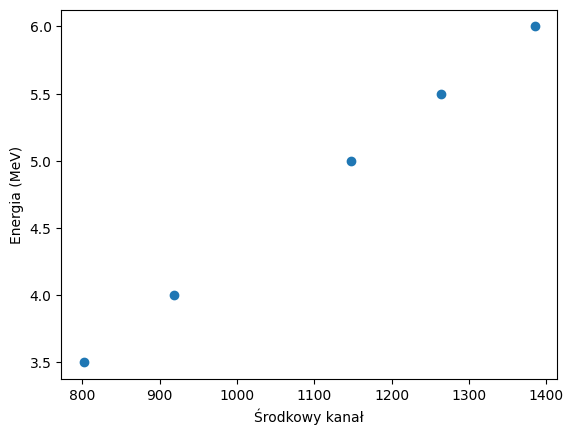

In [6]:
print(f"{'Lp.':<5} | {'Energia [MeV]':<15} | {'Kanał (środek piku)':<15}")
print("-" * 45)

for i, (e, k) in enumerate(zip(energia, kanaly), 1):
    print(f"{i:<5} | {e:<15.2f} | {k:<15.2f}")

plt.figure()
plt.plot(kanaly, energia, 'o')
plt.xlabel("Środkowy kanał")
plt.ylabel("Energia (MeV)")

plt.show()

## Dopasowanie prostej

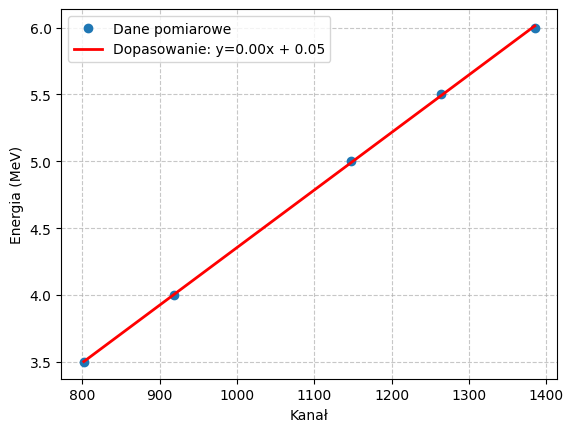

Wyniki dopasowania prostej y = ax + b:
a = (0.0043024950821869455 +/- 2.2912597479900665e-05) MeV/kanał
b = (0.05265760287832082 +/- 0.02575940119021239) MeV


In [10]:
p, V = np.polyfit(kanaly, energia, 1, cov=True)

# Rozpakowanie współczynników
a_fit = p[0]
b_fit = p[1]

# 2. ZMIANA: Obliczanie niepewności
# Niepewność to pierwiastek z elementu na przekątnej macierzy kowariancji V
da = np.sqrt(V[0][0]) # niepewność a
db = np.sqrt(V[1][1]) # niepewność b

# Generowanie punktów do wykresu (bez zmian)
x_fit = np.linspace(min(kanaly), max(kanaly), 100)
y_fit = a_fit * x_fit + b_fit

# Rysowanie (bez zmian)
plt.figure()
plt.plot(kanaly, energia, 'o', markersize=6, label='Dane pomiarowe')
plt.plot(x_fit, y_fit, '-', color='red', linewidth=2, label=f'Dopasowanie: y={a_fit:.2f}x + {b_fit:.2f}')

plt.xlabel("Kanał")
plt.ylabel("Energia (MeV)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# 3. ZMIANA: Wyświetlanie wyników z niepewnościami
print(f"Wyniki dopasowania prostej y = ax + b:")
print(f"a = ({a_fit} +/- {da}) MeV/kanał")
print(f"b = ({b_fit} +/- {db}) MeV")

## Wykres reszt

### Niepewności reszt
W celu określenia niepewności pomiaru wykonano serię pomiarów liczby zliczeń przy ustawieniu aparatury na 4 MeV.


1: 921.54
2: 922.46
3: 923.17
4: 923.91
5: 923.10
6: 922.66
7: 923.45
8: 924.32
9: 923.87
10: 923.73


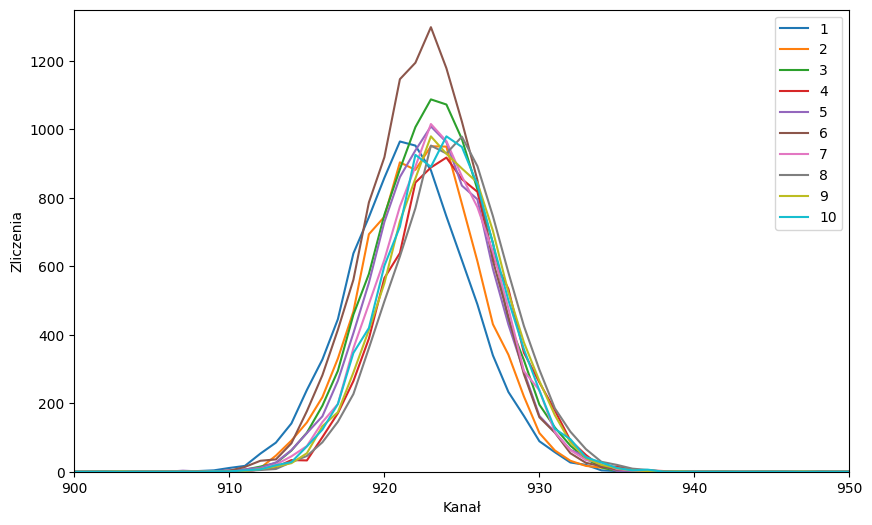

NameError: name 'a' is not defined

In [8]:
pliki_kalibracja_alpha = {
    '1': 'dane/02niepewnosc_kanal/01_4_0MeV.lst.lst',
    '2': 'dane/02niepewnosc_kanal/02_4_0MeV.lst.lst',
    '3': 'dane/02niepewnosc_kanal/03_4_0MeV.lst.lst',
    '4': 'dane/02niepewnosc_kanal/04_4_0MeV.lst.lst',
    '5': 'dane/02niepewnosc_kanal/05_4_0MeV.lst.lst',
    '6': 'dane/02niepewnosc_kanal/06_4_0MeV.lst.lst',
    '7': 'dane/02niepewnosc_kanal/07_4_0MeV.lst.lst',
    '8': 'dane/02niepewnosc_kanal/08_4_0MeV.lst.lst',
    '9': 'dane/02niepewnosc_kanal/09_4_0MeV.lst.lst',
    '10': 'dane/02niepewnosc_kanal/10_4_0MeV.lst.lst',
}

lista_seria_pomiarow_4MeV = []

plt.figure(figsize=(10,6))
for label, path in pliki_kalibracja_alpha.items():
    df = load_lst(path)
    
    A, mu, sigma, fwhm = gaussian_fit_auto(df)
    
    lista_seria_pomiarow_4MeV.append(mu)
    
    print(f'{label}: {mu:.2f}')
    
    plt.plot(df['channel'], df['counts'], label=label)
plt.xlim(900, 950) # Zakres piku alfa
plt.ylim(0,1350)
plt.xlabel("Kanał")
plt.ylabel("Zliczenia")
plt.legend()
plt.show()

seria_pom_4MeV = np.array(lista_seria_pomiarow_4MeV)
u_kanalu = np.std(seria_pom_4MeV, ddof=1)
u_energii = a*u_kanalu

u_energii_arr = np.full_like(kanaly, u_energii)

### Wykres

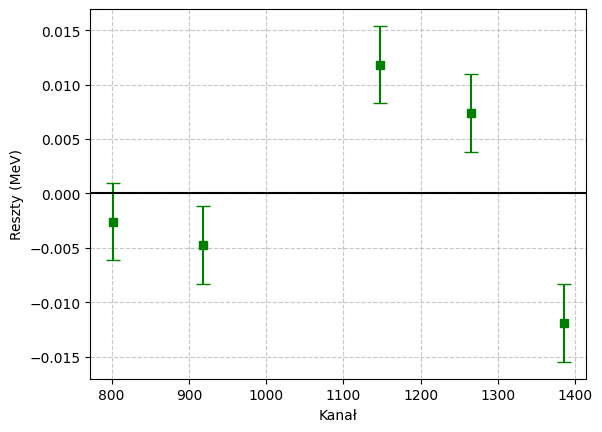

Niepewność energii: 0.0036
Lp.   | Reszta [MeV]    | 3 sigma        
---------------------------------------------
1     | -0.0026         | 0.0107         
2     | -0.0047         | 0.0107         
3     | 0.0118          | 0.0107         
4     | 0.0074          | 0.0107         
5     | -0.0119         | 0.0107         


In [ ]:
y_model = a_fit * kanaly + b_fit
reszty = energia - y_model

plt.errorbar(kanaly, reszty, yerr=u_energii, fmt='s', color='green', capsize=5)
plt.axhline(0, color='black')
plt.xlabel('Kanał')
plt.ylabel('Reszty (MeV)')
plt.grid(True, linestyle='--', alpha=0.7)    

plt.show()
print(f'Niepewność energii: {u_energii:.4f}')

    
print(f"{'Lp.':<5} | {'Reszta [MeV]':<15} | {'3 sigma':<15}")
print("-" * 45)

for i, reszta in enumerate(reszty,1):
    print(f"{i:<5} | {reszta:<15.4f} | {3*u_energii:<15.4f}")